<a href="https://colab.research.google.com/github/Bodaxxt/hands-on-ml3-summary/blob/main/code-snippets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows of data:
   Country  GDP per capita (USD)  Life satisfaction
0   Russia          26456.387938                5.8
1   Greece          27287.083401                5.4
2   Turkey          28384.987785                5.5
3   Latvia          29932.493910                5.9
4  Hungary          31007.768407                5.6

X shape: (27, 1), y shape: (27, 1)


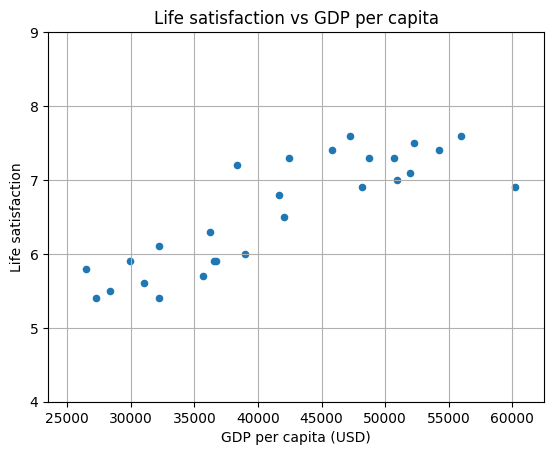


LINEAR REGRESSION RESULTS
Intercept (θ₀): 3.7490
Slope (θ₁): 0.000068

Predicted life satisfaction for Cyprus: 6.30

KNN REGRESSION RESULTS (k=3)
Predicted life satisfaction for Cyprus: 6.33

Indices of 3 nearest neighbors: [11 10  9]
GDP of nearest neighbors: [38341.30757041 36732.03474403 36547.73895598]
Life satisfaction of nearest neighbors: [7.2 5.9 5.9]

Average life satisfaction of 3 neighbors: 6.33
(Same as KNN prediction: 6.33)

COMPARISON
Linear Regression: 6.3017
KNN (k=3):         6.3333
Difference:        0.0317


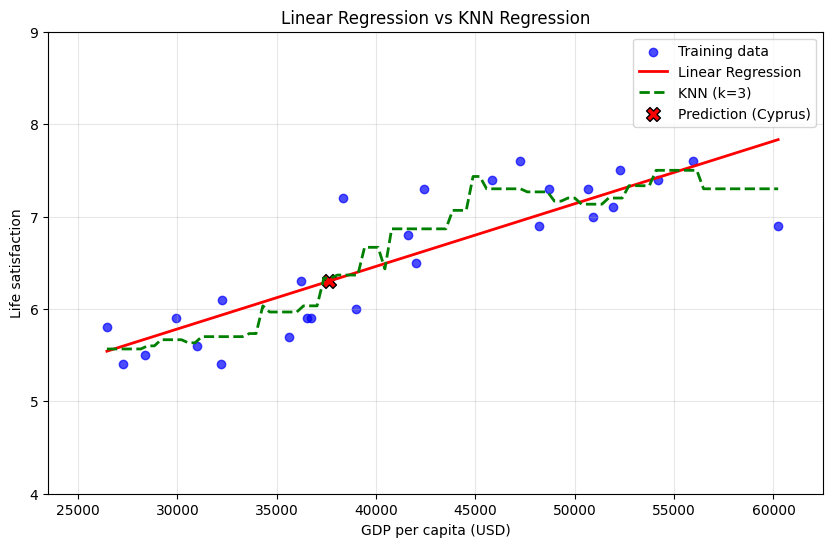


HOW LINEAR REGRESSION FINDS θ₀ AND θ₁
θ₀ (intercept) from Normal Equation: 3.7490
θ₁ (slope) from Normal Equation:     0.000068
(Same as Scikit-Learn? True)

HOW KNN WORKS

All training data:
  GDP: $26,456 → Life satisfaction: 5.8
  GDP: $27,287 → Life satisfaction: 5.4
  GDP: $28,385 → Life satisfaction: 5.5
  GDP: $29,932 → Life satisfaction: 5.9
  GDP: $31,008 → Life satisfaction: 5.6
  GDP: $32,181 → Life satisfaction: 5.4
  GDP: $32,238 → Life satisfaction: 6.1
  GDP: $35,638 → Life satisfaction: 5.7
  GDP: $36,215 → Life satisfaction: 6.3
  GDP: $36,548 → Life satisfaction: 5.9

New point (Cyprus): GDP = $37,655
Finding 3 closest points...
  #1: GDP $38,341 → Life satisfaction 7.2 (Δ = $686)
  #2: GDP $36,732 → Life satisfaction 5.9 (Δ = $923)
  #3: GDP $36,548 → Life satisfaction 5.9 (Δ = $1,107)

KNN prediction = average of these 3 values = 6.33


In [2]:
"""
Chapter 1 – Code Snippets
Example 1-1: Training and running a linear model using Scikit-Learn
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

# ============================================
# PART 1: LOAD AND PREPARE DATA
# ============================================

# Download and prepare the data
data_root = "https://github.com/ageron/data/raw/main/"
lifesat = pd.read_csv(data_root + "lifesat/lifesat.csv")

# Split features (X) and target (y)
X = lifesat[["GDP per capita (USD)"]].values
y = lifesat[["Life satisfaction"]].values

print("First 5 rows of data:")
print(lifesat.head())
print(f"\nX shape: {X.shape}, y shape: {y.shape}")

# ============================================
# PART 2: VISUALIZE THE DATA
# ============================================

# Scatter plot
lifesat.plot(kind='scatter', grid=True,
             x="GDP per capita (USD)", y="Life satisfaction")
plt.axis([23_500, 62_500, 4, 9])
plt.title("Life satisfaction vs GDP per capita")
plt.show()

# ============================================
# PART 3: TRAIN A LINEAR REGRESSION MODEL (Model-Based)
# ============================================

model = LinearRegression()
model.fit(X, y)

print("\n" + "="*50)
print("LINEAR REGRESSION RESULTS")
print("="*50)

# Model parameters
print(f"Intercept (θ₀): {model.intercept_[0]:.4f}")
print(f"Slope (θ₁): {model.coef_[0][0]:.6f}")

# Make a prediction for Cyprus (GDP = $37,655.2)
X_new = [[37_655.2]]
y_pred = model.predict(X_new)
print(f"\nPredicted life satisfaction for Cyprus: {y_pred[0][0]:.2f}")

# ============================================
# PART 4: TRAIN A KNN REGRESSION MODEL (Instance-Based)
# ============================================

knn_model = KNeighborsRegressor(n_neighbors=3)
knn_model.fit(X, y)

print("\n" + "="*50)
print("KNN REGRESSION RESULTS (k=3)")
print("="*50)

y_pred_knn = knn_model.predict(X_new)
print(f"Predicted life satisfaction for Cyprus: {y_pred_knn[0][0]:.2f}")

# Find the 3 nearest neighbors
distances, indices = knn_model.kneighbors(X_new)
print(f"\nIndices of 3 nearest neighbors: {indices[0]}")
print(f"GDP of nearest neighbors: {X[indices[0]].flatten()}")
print(f"Life satisfaction of nearest neighbors: {y[indices[0]].flatten()}")

# Average of 3 neighbors (to verify)

avg = y[indices[0]].mean()
print(f"\nAverage life satisfaction of 3 neighbors: {avg:.2f}")
print(f"(Same as KNN prediction: {y_pred_knn[0][0]:.2f})")

# ============================================
# PART 5: COMPARISON
# ============================================

print("\n" + "="*50)
print("COMPARISON")
print("="*50)
print(f"Linear Regression: {y_pred[0][0]:.4f}")
print(f"KNN (k=3):         {y_pred_knn[0][0]:.4f}")
print(f"Difference:        {abs(y_pred[0][0] - y_pred_knn[0][0]):.4f}")

# ============================================
# PART 6: VISUALIZE BOTH MODELS
# ============================================

# Create a smooth line for predictions
X_smooth = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_linear_smooth = model.predict(X_smooth)
y_knn_smooth = knn_model.predict(X_smooth)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Training data', alpha=0.7)
plt.plot(X_smooth, y_linear_smooth, 'r-', label='Linear Regression', linewidth=2)
plt.plot(X_smooth, y_knn_smooth, 'g--', label=f'KNN (k=3)', linewidth=2)
plt.scatter(X_new, y_pred, color='red', s=100, marker='X',
            label='Prediction (Cyprus)', edgecolors='black')
plt.xlabel("GDP per capita (USD)")
plt.ylabel("Life satisfaction")
plt.title("Linear Regression vs KNN Regression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis([23_500, 62_500, 4, 9])
plt.show()

# ============================================
# BONUS: HOW MODEL PARAMETERS ARE LEARNED
# ============================================

print("\n" + "="*50)
print("HOW LINEAR REGRESSION FINDS θ₀ AND θ₁")
print("="*50)

# Manual calculation using Normal Equation
X_b = np.c_[np.ones((X.shape[0], 1)), X]  # add bias term
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

print(f"θ₀ (intercept) from Normal Equation: {theta_best[0][0]:.4f}")
print(f"θ₁ (slope) from Normal Equation:     {theta_best[1][0]:.6f}")
print(f"(Same as Scikit-Learn? {np.isclose(theta_best[0][0], model.intercept_[0])})")

# ============================================
# UNDERSTANDING KNN
# ============================================

print("\n" + "="*50)
print("HOW KNN WORKS")
print("="*50)

# Show all training points
print("\nAll training data:")
for i in range(min(10, len(X))):
    print(f"  GDP: ${X[i][0]:,.0f} → Life satisfaction: {y[i][0]:.1f}")

print(f"\nNew point (Cyprus): GDP = ${X_new[0][0]:,.0f}")
print(f"Finding 3 closest points...")

for i, idx in enumerate(indices[0]):
    distance = abs(X[idx][0] - X_new[0][0])
    print(f"  #{i+1}: GDP ${X[idx][0]:,.0f} → Life satisfaction {y[idx][0]:.1f} (Δ = ${distance:,.0f})")

print(f"\nKNN prediction = average of these 3 values = {y_pred_knn[0][0]:.2f}")